# Tarea 3

#### Instrucciones:
- La tarea consta de una parte de preguntas y otra de desarrollo de código. Debe entregar todas las respuestas en formato notebook, y cuando la respuesta sea texto, debe hacer en celdas markdown con formato. 
- La entrega de la Tarea es el día **5 de Noviembre, 23:59 hrs.**

## Bosón de Higgs

En esta tarea trabajaremos con datos simulados del bosón de Higgs (versión simplificada), del desafío de [Kaggle](https://www.kaggle.com/c/higgs-boson/overview). Los archivos son Higgs_features.csv y Higgs_labels.csv. Las etiquetas son 0 (no hay señal de Higgs) y 1 (señal de Higgs). Los features son similares a los vistos en el set que utilizamos en clases, tales como energía faltantes, energía, momentum, rapidez transversal y azimutal, etc. Puede encontrar más detalles [acá](https://higgsml.lal.in2p3.fr/files/2014/04/documentation_v1.8.pdf). Note que el set de datos para esta tarea es una versión simplificada.

**1. Lea los datos en dos dataframes o arreglos de numpy, uno para features y otro para etiquetas**

In [1]:
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
features = pd.read_csv('Higgs_features.csv', header=None)
features

,0,1,2,3,4,5,6,7
0,393.335,79.460,308.879,4.095,1.403,-1.411,49.063,39.478
1,71.048,29.291,55.602,2.439,1.667,-1.412,22.926,9.486
2,141.450,87.017,72.091,1.472,4.714,1.233,23.591,69.754
3,156.539,39.797,127.933,4.017,1.279,-1.408,21.415,18.222
4,89.639,34.399,66.741,2.934,1.417,-1.377,26.459,8.257
...,...,...,...,...,...,...,...,...
24995,109.449,58.608,65.599,2.573,1.103,1.201,31.336,29.377
24996,139.483,32.872,96.408,2.439,0.447,1.325,69.421,14.668
24997,78.421,51.766,51.303,2.054,1.225,1.108,26.775,30.509
24998,90.507,70.860,75.535,1.650,1.122,-1.410,45.511,27.279


In [3]:
labels = pd.read_csv('Higgs_labels.csv', header=None)
labels

,0
0,0
1,0
2,0
3,0
4,0
...,...
24995,0
24996,1
24997,0
24998,0


**2. ¿Cuántas instancias y características hay en el set de datos?**

Hay 25000 instancias, y 8 características

**3. Haga un gráfico de la distribución (histograma) de cada feature en el set de datos, en un sólo gráfico. Agregue una leyenda con las etiquetas (Feature 1, Feature 2....etc.) y fije la transparencia de los histogramas (parámetro alpha) en 0.5 para que se noten mejor.** 

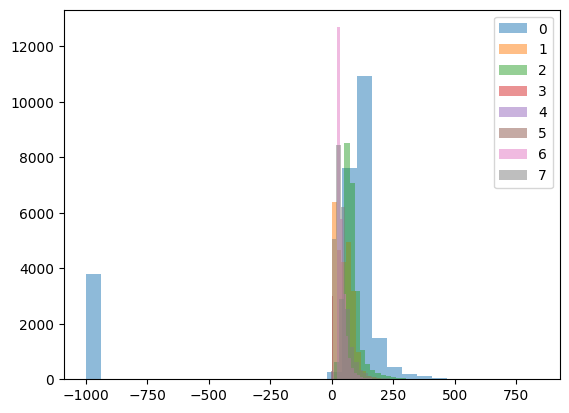

In [4]:
i=0
for col in features: 
    plt.hist(features[col], bins=30, alpha=0.5, label=col)
    
plt.legend()
plt.show()

**4. Observa algo inusual en la distribución de alguna de las features? Qué puede causar este problema?**

Observamos que la feature 0 tiene una distribución muy distinta a las otras features, extendiéndose a valores negativos. De acuerdo al Apéndice B del archivo [Learning to discover: the Higgs boson machine learning challeng](https://higgsml.lal.in2p3.fr/files/2014/04/documentation_v1.8.pdf), si una variable tiene valores de -999.0 es porque no tiene significado o no pudo ser calculada, por lo tanto, sería mejor descartar esta variable, ya que no se pueden reemplazar los valores, y este valor tan alejado de el rango de las demás variables puede afectar significativamente al modelo a crear.

In [5]:
features = features.drop(0, axis=1)

In [6]:
features

,1,2,3,4,5,6,7
0,79.460,308.879,4.095,1.403,-1.411,49.063,39.478
1,29.291,55.602,2.439,1.667,-1.412,22.926,9.486
2,87.017,72.091,1.472,4.714,1.233,23.591,69.754
3,39.797,127.933,4.017,1.279,-1.408,21.415,18.222
4,34.399,66.741,2.934,1.417,-1.377,26.459,8.257
...,...,...,...,...,...,...,...
24995,58.608,65.599,2.573,1.103,1.201,31.336,29.377
24996,32.872,96.408,2.439,0.447,1.325,69.421,14.668
24997,51.766,51.303,2.054,1.225,1.108,26.775,30.509
24998,70.860,75.535,1.650,1.122,-1.410,45.511,27.279


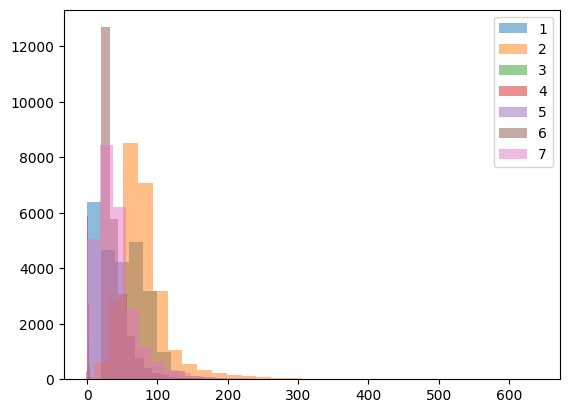

In [7]:
i=0
for col in features: 
    plt.hist(features[col], bins=30, alpha=0.5, label=col)
    
plt.legend()
plt.show()

**5\. ¿Cuántos eventos positivos (Higgs) tiene el data set? Cree que está balanceada la muestra?**

In [8]:
labels.sum()

0    8474
dtype: int64

In [9]:
25000-8474

16526

La clase 1 es la positiva, por lo tanto, la suma entre ellas es la cantidad de eventos positivos. Por otro lado, en el set de datos hay 25000 instancias, y 8474 son positivas, por lo tanto, 16526 son eventos negativos. Esto significa que la muestra no está balanceada, ya que hay alrededor de el doble de eventos negativos.

**6\. En base a su respuesta de la pregunta 5, qué métrica de evaluación (accuracy, precision o recall), escogería para este set de datos?**

Precision, ya que esta se centra más en los verdaderos positivos y falsos positivos, por lo tanto, se sabrá mejor qué tan correctamente se asigna la clase positiva.  En cambio, accuracy no es conveniente ya que la muestra es desbalanceada, y recall no considera los falsos positivos, por lo que esta métrica no reflejará si nuestro modelo es útil o no.

**7\.  Use un clasificador de árbol de decisión y haga validación cruzada en sus datos, usando la métrica que escogió. Reporte el promedio y desviación estándar de los scores obtenidos de los cinco folds**

Recuerde usar StratifiedKFold, que incluya shuffle=True, para asegurar que los datos no estén en un orden específico



In [10]:
from sklearn.tree import DecisionTreeClassifier

model = DecisionTreeClassifier(random_state=10)

In [11]:
from sklearn.model_selection import KFold, StratifiedKFold, cross_val_score

cv = StratifiedKFold(shuffle = True, n_splits = 5, random_state=5)

In [12]:
from sklearn.model_selection import cross_validate, cross_val_predict

scores = cross_validate(model, features, labels, cv = cv, scoring = 'precision',return_train_score=True)

In [13]:
train_scores = scores['train_score']
test_scores = scores['test_score']

print("Scores de entrenamiento:", train_scores)
print("Scores de prueba:", test_scores)

Scores de entrenamiento: [1. 1. 1. 1. 1.]
Scores de prueba: [0.61688312 0.60763098 0.63236169 0.61616162 0.62454874]


In [14]:
import numpy as np

test_mean = np.mean(test_scores)
test_std = np.std(test_scores)

print(f"\nPromedio del score de prueba: {test_mean:.4f}")
print(f"Desviación estándar del score de prueba: {test_std:.4f}")


Promedio del score de prueba: 0.6195
Desviación estándar del score de prueba: 0.0084


In [15]:
train_mean = np.mean(train_scores)
train_std = np.std(train_scores)

print(f"\nPromedio del score de entrenamiento: {train_mean:.4f}")
print(f"Desviación estándar del score de entrenamiento: {train_std:.4f}")


Promedio del score de entrenamiento: 1.0000
Desviación estándar del score de entrenamiento: 0.0000


**8\. Genere las etiquetas predichas usando cross_val_predict, y luego imprima la matriz de confusión**

In [16]:
ypred = cross_val_predict(model,features,labels,cv=cv)

In [17]:
from sklearn.metrics import confusion_matrix
cm = confusion_matrix(labels, ypred)

In [18]:
cm

array([[13300,  3226],
       [ 3224,  5250]])

**9\. Dada la matriz de confusión, indique los valores de TP, TN, FP, FN. Tiene más errores de FP o FN?**

Según la matriz de confusión, existen 13300 verdaderos positivos, 5250 verdaderos negaticos, 3226 falsos positivos, y 3224 falsos negativos. Existen solo dos más falsos positivos que falsos negativos.

**10\. Ahora usemos un clasificador usando SVM. Usando SVC, deje los parámetros del clasificador los que viene por defecto y haga una validación cruzada con k=5 y reporte los scores, como hizo antes con el árbol de decisión. ¿Qué algoritmo tiene mejor performance?
Nota: SVMs es un algoritmo lento y puede tomar tiempo este cálculo. Si toma demasiado tiempo, reduzca el número de folds (no menos de 3).**

In [19]:
from sklearn.svm import SVC, LinearSVC
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline
import numpy as np

In [20]:
piped_model = make_pipeline(StandardScaler(), LinearSVC(dual=False, C=1000))

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=101)

resultados = cross_validate(piped_model, features, labels, cv=cv, scoring='precision', return_train_score=True)

print("Promedio del score de prueba:", resultados['test_score'].mean())
print("Desviación estándar del score de prueba:", resultados['test_score'].std())
print("Promedio del score de entrenamiento:", resultados['train_score'].mean())
print("Desviación estándar del score de entrenamiento:", resultados['train_score'].std())

Promedio del score de prueba: 0.6371252665561297
Desviación estándar del score de prueba: 0.011966281195060768
Promedio del score de entrenamiento: 0.6375045302853233
Desviación estándar del score de entrenamiento: 0.0015566862988846705


c:\Users\javie\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\utils\validation.py:1339: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)
c:\Users\javie\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\utils\validation.py:1339: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)
c:\Users\javie\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\utils\validation.py:1339: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)
c:\Users\javie\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\utils\validation.py:1339: DataC

Podemos observar que el modelo SVM presenta un score de prueba de 0.63, siendo más alto que el de el árbol de desición, es decir, tiene un mejor desempeño al presentarle datos nuevos. Por otro lado, el árbol de desición al presentar un score de entrenamiento de 1, está sobre ajustando. Acerca de la desviación estandar, los dos modelos presentan baja desviación estandar.

Con los argumentos anteriores, se puede decir que el modelo SVM presenta mejor performance, y la razón de más peso es que no muestra sobre ajuste y score de prueba es alto.

**11\. Reporte la matriz de confusión para el algoritmo de SVC. Hay algún cambio de los valores de FP y FN respecto al modelo de árbol de decisión?**

In [21]:
y_pred_svm = cross_val_predict(piped_model, features, labels, cv=cv)
matriz_conf = confusion_matrix(labels, y_pred_svm)
matriz_conf

c:\Users\javie\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\utils\validation.py:1339: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)
c:\Users\javie\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\utils\validation.py:1339: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)
c:\Users\javie\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\utils\validation.py:1339: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)
c:\Users\javie\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\utils\validation.py:1339: DataC

array([[14369,  2157],
       [ 4691,  3783]])

Resumiendo la información de los dos modelos tenemos lo siguiente:

**Árbol de desición**

- TP: 13300
- FP: 3226
- TN: 5250
- FN: 3224

**SVM**

- TP: 14369
- FP: 2157
- TN: 3783
- FN: 4691


Podemos ver que en el módelo SVM se presentan menos falsos positivos pero aumentan los falsos negativos en comparación al modelo de Árbol de desición. Por otro lado SVM también identifica más verdaderos positivos que el árbol de desición, y el módelo de árbol de desición tiene más verdaderos negativos en comparación a SVM.

**12\. Intente optimizar los parámetros de SVC. Para evitar que tome demasiado tiempo, seleccione solo el primer 5% de los datos (asegúrese de desordenarlos antes)**


Para seleccionar 5% de los datos, podemos usar la función .sample de pandas, lo cual seleccionará de forma aleatoria esta fracción de datos. Luego, obteniendo los indices de estas filas aleatorias, se pueden obtener sus respectivas labels.

In [22]:
features_sample = features.sample(frac=0.05, random_state=101)
labels_sample = labels.loc[features_sample.index]

In [23]:
labels_sample = labels_sample.values.ravel()

In [27]:
from sklearn.model_selection import GridSearchCV

piped_model = make_pipeline(StandardScaler(), SVC())
parameters = {'svc__kernel': ['linear', 'rbf'],'svc__gamma': [0.01, 0.25, 0.5], 'svc__C': [0.1, 1, 10], 'svc__degree': [2, 4, 8]}

model = GridSearchCV(piped_model, parameters, cv=cv, scoring='precision', verbose=2, n_jobs=4, return_train_score=True)

model.fit(features_sample, labels_sample)

print("Mejores parámetros:", model.best_params_)
print("Mejor precisión en validación:", model.best_score_)

Fitting 5 folds for each of 54 candidates, totalling 270 fits
Mejores parámetros: {'svc__C': 0.1, 'svc__degree': 2, 'svc__gamma': 0.5, 'svc__kernel': 'rbf'}
Mejor precisión en validación: 0.7468957633445316


Al intentar optimizar los parámetros probando con algunas combinacions, el mejor score que se tiene es de 0.74, por lo tanto, el modelo mejoró su rendimiento en un 11%. Esto indica que es recomendable, o que vale la pena, optimizar los parámetros para una mejor predicción.

**13\. Haga un esquema de CV con GridSearch, con los siguientes valores de parámetros:
parameters = {'kernel':['linear','rbf'],'C':[1, 10, 100], 'gamma':[0.01, 0.1, 0.5], 'class_weight':[{1:1},{1:3},{1:5}]}**

**Recuerde seguir usando la métrica que eligió más arriba.**

**Esto tomará tiempo! Fije verbose=2 en GridSearch para monitorear el progreso, y njobs=4 o más para acelerar un poco el proceso.**

**Reporte los parámetros y scores del mejor modelo**

In [24]:
from sklearn.model_selection import GridSearchCV

piped_model = make_pipeline(StandardScaler(), SVC())
parameters = {'svc__kernel': ['linear', 'rbf'], 'svc__C': [1, 10, 100],'svc__gamma': [0.01, 0.1, 0.5], 'svc__class_weight': [{1:1}, {1:3}, {1:5}]}

model = GridSearchCV(piped_model, parameters, cv=cv, scoring='precision', verbose=2, n_jobs=4, return_train_score=True)

model.fit(features_sample, labels_sample)

print("Mejores parámetros:", model.best_params_)
print("Mejor precisión en validación:", model.best_score_)

Fitting 5 folds for each of 54 candidates, totalling 270 fits
Mejores parámetros: {'svc__C': 1, 'svc__class_weight': {1: 1}, 'svc__gamma': 0.5, 'svc__kernel': 'rbf'}
Mejor precisión en validación: 0.722966511966512


Vemos que con estos parámetros, el modelo tambien mejoró su rendimiento en comparación a cuando no hicimos una GridSearch, aumentando el score en un 9%. Por lo tanto, creemos que en cualquier caso es mejor realizar la optimización de parámetros, ya que el rendimiento mejorará en algún porcentaje. Notamos que con los parámetros usados en este inciso, el modelo mejoró su score en una menor cantidad a difencia de los parámetros usados en el inciso anterior. Por lo tanto, creemos que podría ser conveniente hacer GridSearch usando más parámetros, ya que podría haber una combinación mejor a las usadas en estos ejercicios. Sin embargo, no deberíamos utilizar una cantidad muy grande de combinaciones, ya que demoraría mucho más tiempo.

**14\. En base a sus resultados, cuál algoritmo de clasificación recomendaría para este problema, árbol de decisión o SVC?**

Para este problema, recomendaríamos utilizar SVC. Esto se debe principalmente a que los datos con los que trabajamos no presentan una relación lineal, lo que hace que el problema sea más complejo, y el modelo SVC es ideal para ajustar estos datos, ya que permite trabajar con hiperparámetros que se pueden optimizar para evitar tanto el sobreajuste como el subajuste, por lo que nos parece un modelo más robusto. Por otro lado, los árboles de decisión son modelos más simples y un poco limitados en comparación con el SVC. Esta diferencia en la capacidad de ajuste se refleja en los resultados obtenidos: con SVC, el máximo score que obtuvimos fue de 0.74, mientras que con el árbol de decisión el score fue 0.6195. Es importante destacar que, al emplear SVC, solo utilizamos el 5% de los datos. Por lo tanto, la comparación entre ambos modelos es limitada. Sería bueno poder evaluar cómo se comporta el modelo utilizando todo el conjunto de datos. De todas formas, nuestra hipótesis es que el modelo SVC tendría un mejor rendimiento al estar mejor entrenado con más datos. Aun así, el tiempo de entrenamiento aumentaría, ya que encontrar los mejores parámetros llevaría más tiempo, y además el modelo podría ser más susceptible al sobreajuste.